Rows: 144
Columns: ['translation1', 'translation2', 'original_label', 'genre', 'pairID']

Missing values per column:
 translation1      0
translation2      0
original_label    0
genre             0
pairID            0
dtype: int64

Unique labels: ['contradiction', 'entailment', 'neutral']

Label counts:
 original_label
entailment       62
neutral          55
contradiction    27
Name: count, dtype: int64


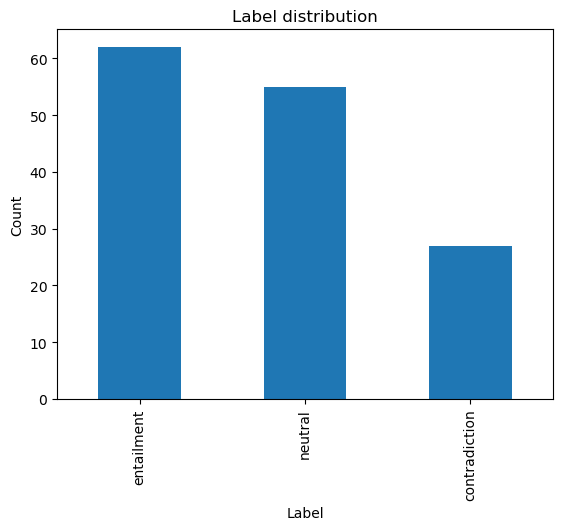


Genre counts:
 genre
negation           40
coreference        37
quantifiers        30
numbers            13
neutral_trap       10
lexical             7
lexical_overlap     3
politics            2
logic               2
Name: count, dtype: int64


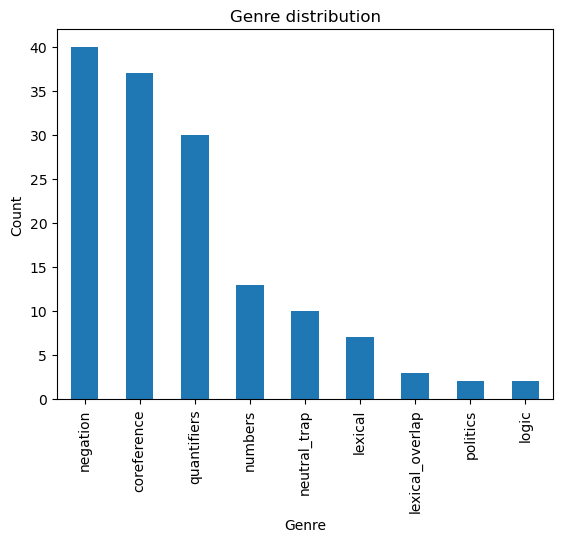


Label x Genre counts:
 genre           coreference  lexical  lexical_overlap  logic  negation  \
original_label                                                           
contradiction             3        1                0      0        10   
entailment               21        3                2      2        16   
neutral                  13        3                1      0        14   

genre           neutral_trap  numbers  politics  quantifiers  
original_label                                                
contradiction              0        4         0            9  
entailment                 0        6         1           11  
neutral                   10        3         1           10  


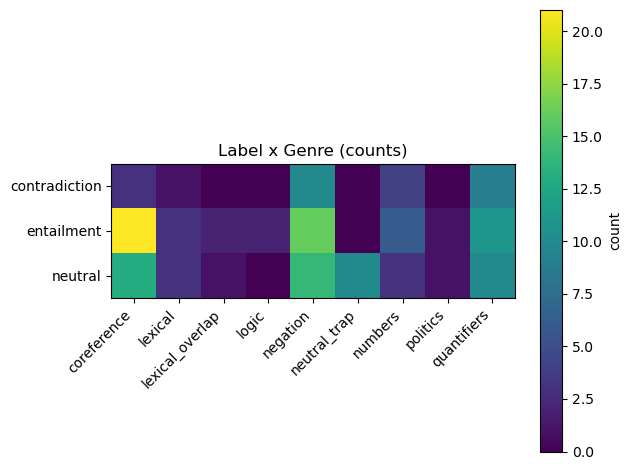


Length stats (chars):
t1: {'mean': 44.46527777777778, 'p50': 46.0, 'p90': 54.70000000000002, 'p95': 56.0, 'p99': 60.0, 'max': 63.0}
t2: {'mean': 26.52777777777778, 'p50': 27.0, 'p90': 35.0, 'p95': 36.0, 'p99': 40.0, 'max': 41.0}
pair: {'mean': 70.99305555555556, 'p50': 72.0, 'p90': 86.70000000000002, 'p95': 88.85, 'p99': 94.70999999999998, 'max': 99.0}


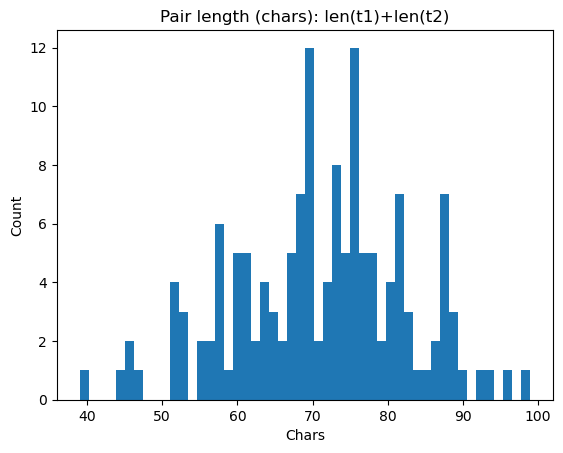


Duplicate exact pairs: 0

Examples per label:

--- entailment ---
t1: הפרויקט היה מאתגר ומעניין לכל המשתתפים.
t2: הפרויקט היה מאתגר.
genre: lexical_overlap

t1: בחדר ישיבות ישבו שמונה מנהלים ושלושה יועצים.
t2: בחדר ישיבות ישבו יותר מעשרה אנשים.
genre: quantifiers

t1: השרה הודיעה כי היא תתמוך בחוק החדש לאחר שקראה את כל סעיפיו.
t2: השרה קראה את החוק.
genre: politics


--- contradiction ---
t1: בכיתה יש בדיוק עשרים תלמידים, וחצי מהם בנות.
t2: רוב התלמידים בכיתה הן בנות.
genre: numbers

t1: אף אחד לא הצליח לפתור את החידה המורכבת של המורה.
t2: תלמיד אחד מצא את התשובה בסוף.
genre: quantifiers

t1: אף מדינה באירופה לא הסכימה לקבל את התנאים החדשים.
t2: חלק מהמדינות האירופאיות חתמו על ההסכם.
genre: negation


--- neutral ---
t1: החברה הודיעה על פיטורי עשרה אחוזים מכוח האדם שלה.
t2: החברה עומדת בפני פשיטת רגל.
genre: neutral_trap

t1: הקבוצה המקומית מעולם לא הפסידה במשחק ביתי העונה.
t2: הקבוצה ניצחה בכל משחקי הבית שלה.
genre: negation

t1: לא ייתכן שהשומר לא ראה את הפריצה כשהיא התרחשה.
t2: השו

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

jsonl_path = "./allData/HebNLI_train_new_data.clean.jsonl"

df = pd.read_json(jsonl_path, lines=True)

# 1) סקירה כללית
print("Rows:", len(df))
print("Columns:", df.columns.tolist())
print("\nMissing values per column:\n", df.isna().sum())

# 2) בדיקת labels
print("\nUnique labels:", sorted(df["original_label"].astype(str).str.lower().unique()))
label_counts = df["original_label"].astype(str).str.lower().value_counts()
print("\nLabel counts:\n", label_counts)

plt.figure()
label_counts.plot(kind="bar")
plt.title("Label distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

# 3) בדיקת genre
genre_counts = df["genre"].astype(str).value_counts()
print("\nGenre counts:\n", genre_counts)

plt.figure()
genre_counts.plot(kind="bar")
plt.title("Genre distribution")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.show()

# 4) טבלת Label x Genre
pivot = pd.crosstab(df["original_label"].astype(str).str.lower(), df["genre"].astype(str))
print("\nLabel x Genre counts:\n", pivot)

plt.figure()
plt.imshow(pivot.values)
plt.title("Label x Genre (counts)")
plt.xticks(range(len(pivot.columns)), pivot.columns, rotation=45, ha="right")
plt.yticks(range(len(pivot.index)), pivot.index)
plt.colorbar(label="count")
plt.tight_layout()
plt.show()

# 5) אורכי טקסט (חשוב ל-max_length של BERT)
df["t1"] = df["translation1"].astype(str)
df["t2"] = df["translation2"].astype(str)

df["len_t1_chars"] = df["t1"].str.len()
df["len_t2_chars"] = df["t2"].str.len()
df["len_pair_chars"] = df["len_t1_chars"] + df["len_t2_chars"]

def stats(series):
    return {
        "mean": float(series.mean()),
        "p50": float(np.percentile(series, 50)),
        "p90": float(np.percentile(series, 90)),
        "p95": float(np.percentile(series, 95)),
        "p99": float(np.percentile(series, 99)),
        "max": float(series.max()),
    }

print("\nLength stats (chars):")
print("t1:", stats(df["len_t1_chars"]))
print("t2:", stats(df["len_t2_chars"]))
print("pair:", stats(df["len_pair_chars"]))

plt.figure()
plt.hist(df["len_pair_chars"], bins=50)
plt.title("Pair length (chars): len(t1)+len(t2)")
plt.xlabel("Chars")
plt.ylabel("Count")
plt.show()

# 6) כפילויות
dup_pairs = df.duplicated(subset=["translation1", "translation2"]).sum()
print("\nDuplicate exact pairs:", dup_pairs)

# 7) דוגמאות רנדומליות לכל label (בדיקת sanity)
print("\nExamples per label:")
for lab in ["entailment", "contradiction", "neutral"]:
    sample = df[df["original_label"].astype(str).str.lower() == lab].sample(3, random_state=42)
    print("\n---", lab, "---")
    for _, r in sample.iterrows():
        print("t1:", r["translation1"])
        print("t2:", r["translation2"])
        print("genre:", r["genre"])
        print()


In [3]:
"""
JSONL EDA Script - Analyze NLI Error Types
Analyzes distribution of error types in your Hebrew NLI dataset
"""

import json
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

def load_jsonl(filepath):
    """Load JSONL file into list of dictionaries"""
    data = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            data.append(json.loads(line.strip()))
    return data

def analyze_error_types(data):
    """Analyze distribution of error types (genres)"""
    
    # Count genres
    genre_counts = Counter([item.get('genre', 'unknown') for item in data])
    
    print("=" * 70)
    print("ERROR TYPE DISTRIBUTION")
    print("=" * 70)
    
    total = len(data)
    for genre, count in genre_counts.most_common():
        percentage = (count / total) * 100
        print(f"{genre:30s}: {count:4d} ({percentage:5.1f}%)")
    
    print(f"\nTotal examples: {total}")
    
    return genre_counts

def analyze_labels(data):
    """Analyze distribution of labels"""
    
    label_counts = Counter([item.get('original_label', 'unknown') for item in data])
    
    print("\n" + "=" * 70)
    print("LABEL DISTRIBUTION")
    print("=" * 70)
    
    total = len(data)
    for label, count in label_counts.most_common():
        percentage = (count / total) * 100
        print(f"{label:30s}: {count:4d} ({percentage:5.1f}%)")
    
    return label_counts

def analyze_genre_by_label(data):
    """Cross-tabulation of genres and labels"""
    
    df = pd.DataFrame(data)
    
    print("\n" + "=" * 70)
    print("CROSS-TABULATION: GENRE x LABEL")
    print("=" * 70)
    
    crosstab = pd.crosstab(
        df['genre'], 
        df['original_label'], 
        margins=True
    )
    
    print(crosstab)
    
    return crosstab

def analyze_text_length(data):
    """Analyze text lengths"""
    
    premise_lengths = [len(item['translation1'].split()) for item in data]
    hypothesis_lengths = [len(item['translation2'].split()) for item in data]
    
    print("\n" + "=" * 70)
    print("TEXT LENGTH STATISTICS (in words)")
    print("=" * 70)
    
    print(f"\nPremise (translation1):")
    print(f"  Mean: {sum(premise_lengths)/len(premise_lengths):.1f} words")
    print(f"  Min:  {min(premise_lengths)} words")
    print(f"  Max:  {max(premise_lengths)} words")
    
    print(f"\nHypothesis (translation2):")
    print(f"  Mean: {sum(hypothesis_lengths)/len(hypothesis_lengths):.1f} words")
    print(f"  Min:  {min(hypothesis_lengths)} words")
    print(f"  Max:  {max(hypothesis_lengths)} words")
    
    return premise_lengths, hypothesis_lengths

def check_target_coverage(data, target_errors):
    """Check how well we're covering the target error types"""
    
    print("\n" + "=" * 70)
    print("TARGET ERROR TYPE COVERAGE")
    print("=" * 70)
    
    genre_counts = Counter([item.get('genre', 'unknown') for item in data])
    
    print(f"\nTarget errors to address:")
    total_target = sum(target_errors.values())
    for error_type, count in target_errors.items():
        percentage = (count / total_target) * 100
        print(f"  {error_type:25s}: {count:3d} errors ({percentage:5.1f}%)")
    
    print(f"\nYour dataset coverage:")
    total_dataset = len(data)
    for error_type, target_count in target_errors.items():
        dataset_count = sum(1 for item in data if error_type.lower() in item.get('genre', '').lower())
        coverage = (dataset_count / target_count) * 100 if target_count > 0 else 0
        print(f"  {error_type:25s}: {dataset_count:3d} examples ({coverage:5.1f}% of target)")
    
    # Overall coverage
    total_created = len(data)
    print(f"\nTotal examples created: {total_created}")
    print(f"Total errors to address: {total_target}")
    print(f"Coverage ratio: {total_created / total_target:.2f}x")

def visualize_distributions(genre_counts, label_counts, crosstab, output_prefix='eda'):
    """Create visualization plots"""
    
    # Set style
    sns.set_style("whitegrid")
    plt.rcParams['font.family'] = 'DejaVu Sans'
    
    # Create figure with subplots
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # 1. Genre distribution
    genres = list(genre_counts.keys())
    counts = list(genre_counts.values())
    axes[0, 0].bar(genres, counts, color='steelblue')
    axes[0, 0].set_title('Error Type Distribution', fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('Error Type (Genre)')
    axes[0, 0].set_ylabel('Count')
    axes[0, 0].tick_params(axis='x', rotation=45)
    
    # Add count labels on bars
    for i, (g, c) in enumerate(zip(genres, counts)):
        axes[0, 0].text(i, c, str(c), ha='center', va='bottom')
    
    # 2. Label distribution
    labels = list(label_counts.keys())
    label_vals = list(label_counts.values())
    colors = ['#2ecc71', '#e74c3c', '#f39c12']  # green, red, orange
    axes[0, 1].pie(label_vals, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
    axes[0, 1].set_title('Label Distribution', fontsize=14, fontweight='bold')
    
    # 3. Heatmap of genre x label
    crosstab_no_margin = crosstab.iloc[:-1, :-1]  # Remove margin row/col
    sns.heatmap(crosstab_no_margin, annot=True, fmt='d', cmap='YlOrRd', ax=axes[1, 0])
    axes[1, 0].set_title('Genre × Label Cross-tabulation', fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel('Label')
    axes[1, 0].set_ylabel('Genre')
    
    # 4. Genre distribution as percentage
    total = sum(counts)
    percentages = [(c/total)*100 for c in counts]
    axes[1, 1].barh(genres, percentages, color='coral')
    axes[1, 1].set_title('Error Type Distribution (%)', fontsize=14, fontweight='bold')
    axes[1, 1].set_xlabel('Percentage')
    axes[1, 1].set_ylabel('Error Type (Genre)')
    
    # Add percentage labels
    for i, (g, p) in enumerate(zip(genres, percentages)):
        axes[1, 1].text(p, i, f'{p:.1f}%', va='center')
    
    plt.tight_layout()
    plt.savefig(f'{output_prefix}_visualization.png', dpi=300, bbox_inches='tight')
    print(f"\n✓ Visualization saved to: {output_prefix}_visualization.png")
    plt.close()

def show_sample_examples(data, n=3):
    """Display sample examples from each error type"""
    
    print("\n" + "=" * 70)
    print("SAMPLE EXAMPLES BY ERROR TYPE")
    print("=" * 70)
    
    genres = set([item.get('genre', 'unknown') for item in data])
    
    for genre in sorted(genres):
        print(f"\n{genre.upper()}:")
        print("-" * 70)
        
        genre_examples = [item for item in data if item.get('genre') == genre]
        
        for i, example in enumerate(genre_examples[:n], 1):
            print(f"\nExample {i}:")
            print(f"  Premise:    {example['translation1']}")
            print(f"  Hypothesis: {example['translation2']}")
            print(f"  Label:      {example['original_label']}")

def main(filepath, target_errors=None):
    """Main EDA function"""
    
    print("\n" + "=" * 70)
    print("NLI DATASET EDA - ERROR TYPE ANALYSIS")
    print("=" * 70)
    print(f"\nLoading data from: {filepath}\n")
    
    # Load data
    data = load_jsonl(filepath)
    
    # Default target errors (your original problem)
    if target_errors is None:
        target_errors = {
            'Coreference': 19,
            'Quantifiers': 7,
            'Negation': 6,
            'Lexical overlap': 1
        }
    
    # Perform analyses
    genre_counts = analyze_error_types(data)
    label_counts = analyze_labels(data)
    crosstab = analyze_genre_by_label(data)
    premise_lengths, hypothesis_lengths = analyze_text_length(data)
    check_target_coverage(data, target_errors)
    
    # Show examples
    show_sample_examples(data, n=2)
    
    # Visualize
    try:
        visualize_distributions(genre_counts, label_counts, crosstab)
    except Exception as e:
        print(f"\n[Warning] Could not create visualizations: {e}")
        print("Install matplotlib and seaborn: pip install matplotlib seaborn")
    
    # Save summary report
    report_file = filepath.replace('.jsonl', '_eda_report.txt')
    with open(report_file, 'w', encoding='utf-8') as f:
        f.write("NLI DATASET EDA REPORT\n")
        f.write("=" * 70 + "\n\n")
        f.write(f"Total examples: {len(data)}\n\n")
        f.write("Genre Distribution:\n")
        for genre, count in genre_counts.most_common():
            f.write(f"  {genre}: {count}\n")
        f.write("\nLabel Distribution:\n")
        for label, count in label_counts.most_common():
            f.write(f"  {label}: {count}\n")
    
    print(f"\n✓ Summary report saved to: {report_file}")
    
    print("\n" + "=" * 70)
    print("EDA COMPLETE")
    print("=" * 70)

# Example usage
if __name__ == "__main__":
    # Replace with your JSONL file path
    filepath = "./allData/HebNLI_train_new_data.clean.jsonl"
    
    # Your target error distribution
    target_errors = {
        'Coreference': 19,
        'Quantifiers': 7,
        'Negation': 6,
        'Lexical overlap': 1
    }
    
    main(filepath, target_errors)


NLI DATASET EDA - ERROR TYPE ANALYSIS

Loading data from: ./allData/HebNLI_train_new_data.clean.jsonl

ERROR TYPE DISTRIBUTION
negation                      :   40 ( 27.8%)
coreference                   :   37 ( 25.7%)
quantifiers                   :   30 ( 20.8%)
numbers                       :   13 (  9.0%)
neutral_trap                  :   10 (  6.9%)
lexical                       :    7 (  4.9%)
lexical_overlap               :    3 (  2.1%)
politics                      :    2 (  1.4%)
logic                         :    2 (  1.4%)

Total examples: 144

LABEL DISTRIBUTION
entailment                    :   62 ( 43.1%)
neutral                       :   55 ( 38.2%)
contradiction                 :   27 ( 18.8%)

CROSS-TABULATION: GENRE x LABEL
original_label   contradiction  entailment  neutral  All
genre                                                   
coreference                  3          21       13   37
lexical                      1           3        3    7
lexical_overlap   

In [5]:
"""
Quick Check Script - Fast analysis of JSONL file
Run this for a quick summary of your dataset
"""

import json
from collections import Counter

def quick_check(filepath):
    """Quick analysis of JSONL file"""
    
    # Load data
    data = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            data.append(json.loads(line.strip()))
    
    print("\n" + "="*70)
    print(f"QUICK ANALYSIS: {filepath}")
    print("="*70)
    
    # Total count
    print(f"\n📊 Total examples: {len(data)}")
    
    # Genre (error type) distribution
    genres = Counter([item.get('genre', 'unknown') for item in data])
    print(f"\n🎯 Error Type Distribution:")
    for genre, count in genres.most_common():
        print(f"   • {genre:25s}: {count:3d} examples")
    
    # Label distribution
    labels = Counter([item.get('original_label', 'unknown') for item in data])
    print(f"\n🏷️  Label Distribution:")
    for label, count in labels.most_common():
        print(f"   • {label:25s}: {count:3d} examples")
    
    # Target coverage
    target_errors = {
        'coreference': 19,
        'quantifiers': 7,
        'negation': 6,
        'lexical': 1
    }
    
    print(f"\n✅ Coverage Check (vs. original errors):")
    for error_type, target_count in target_errors.items():
        actual_count = sum(1 for item in data if error_type in item.get('genre', '').lower())
        coverage = (actual_count / target_count) * 100 if target_count > 0 else 0
        status = "✓" if actual_count >= target_count else "⚠"
        print(f"   {status} {error_type:15s}: {actual_count:3d}/{target_count:2d} ({coverage:5.1f}%)")
    
    # Recommendation
    total_target = sum(target_errors.values())
    if len(data) >= total_target * 2:
        print(f"\n🎉 Great! You have {len(data)} examples (>2x the original errors)")
    elif len(data) >= total_target:
        print(f"\n👍 Good! You have {len(data)} examples (covering all error types)")
    else:
        print(f"\n⚠️  You have {len(data)} examples. Consider adding more (target: {total_target}+)")
    
    print("\n" + "="*70 + "\n")

if __name__ == "__main__":
    import sys
    
    if len(sys.argv) > 1:
        filepath = sys.argv[1]
    else:
        # Default filename
        filepath = input("Enter JSONL file path: ")
    
    quick_check('./allData/HebNLI_train_new_data.clean.jsonl')


QUICK ANALYSIS: ./allData/HebNLI_train_new_data.clean.jsonl

📊 Total examples: 144

🎯 Error Type Distribution:
   • negation                 :  40 examples
   • coreference              :  37 examples
   • quantifiers              :  30 examples
   • numbers                  :  13 examples
   • neutral_trap             :  10 examples
   • lexical                  :   7 examples
   • lexical_overlap          :   3 examples
   • politics                 :   2 examples
   • logic                    :   2 examples

🏷️  Label Distribution:
   • entailment               :  62 examples
   • neutral                  :  55 examples
   • contradiction            :  27 examples

✅ Coverage Check (vs. original errors):
   ✓ coreference    :  37/19 (194.7%)
   ✓ quantifiers    :  30/ 7 (428.6%)
   ✓ negation       :  40/ 6 (666.7%)
   ✓ lexical        :  10/ 1 (1000.0%)

🎉 Great! You have 144 examples (>2x the original errors)


